In [2]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("darkgrid")
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow import keras

In [4]:
from keras.datasets import cifar10, mnist

In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_val,y_train, y_val = train_test_split(X_train, y_train,
                                                 test_size=10000, random_state=42)

In [8]:
X_train,X_val, X_test=X_train/255,X_val/255, X_test/255

In [9]:
class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]

In [10]:
total_classes = len(np.unique(y_train))
total_classes

10

In [11]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [12]:
from keras import regularizers

In [13]:
lambda_reg = 0.001
reg = regularizers.l1(lambda_reg)
#reg = regularizers.l2(lambda_reg)
#reg=regularizers.l1_l2(l1=0.001, l2=0.005)

In [14]:
i = keras.layers.Input(shape=X_train.shape[1:])

x = keras.layers.Conv2D(32,(3,3), padding="same",
                        kernel_regularizer=reg)(i)

x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D(pool_size=(2,2))(x)

x = keras.layers.Conv2D(64,(3,3), padding="same",
                        kernel_regularizer=reg)(x)

x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D(pool_size=(2,2))(x)

x = keras.layers.Conv2D(128,(3,3), padding="same",
                        kernel_regularizer=reg)(x)

x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D(pool_size=(2,2))(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(512, name ="HL1", kernel_regularizer=reg)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.Dropout(0.5)(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, name ="HL2", kernel_regularizer=reg)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.Dropout(0.5)(x)

x = keras.layers.Dense(total_classes, activation="softmax")(x)

In [15]:
model = keras.models.Model(inputs=[i], outputs=[x])

In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HL1 (Dense)                     │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HL2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,280,202 (4.88 MB)

 Trainable params: 1,278,218 (4.88 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [17]:
optimizer=keras.optimizers.Adam(learning_rate=1e-3)

In [18]:
early_stopping_cb=keras.callbacks.EarlyStopping(patience=5,
                                                monitor = "val_loss",
                                                restore_best_weights=True)

In [19]:
chk_pt = keras.callbacks.ModelCheckpoint("cifar10_model.keras",
                                         save_best_only = True,
                                         monitor = 'val_loss')

In [20]:
callbacks = [early_stopping_cb, chk_pt]

In [21]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [22]:
history = model.fit(X_train,y_train, epochs=20, batch_size=32,
                    validation_data=(X_val,y_val),
                    callbacks=callbacks)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3553 - loss: 15.5589 - val_accuracy: 0.3907 - val_loss: 5.0962
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5051 - loss: 4.5359 - val_accuracy: 0.4352 - val_loss: 4.2482
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5432 - loss: 3.8460 - val_accuracy: 0.5797 - val_loss: 3.2870
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5722 - loss: 3.2575 - val_accuracy: 0.4164 - val_loss: 3.6271
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5785 - loss: 3.0869 - val_accuracy: 0.5752 - val_loss: 3.0697
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5895 - loss: 3.0033 - val_accuracy: 0.5506 - val_loss: 3.0586
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5944 - loss: 2.9480 - val_accuracy: 0.5721 - val_loss: 3.0283
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6039 - loss: 2.8961

In [23]:
loss, accuracy = model.evaluate(X_test,y_test)
print(f"Test Accuracy: {accuracy*100:3f}%")
print(f"Test Loss: {loss:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6202 - loss: 2.5114
Test Accuracy: 62.599999%
Test Loss: 2.509


In [24]:
X_new = X_test[:10]
y_pred = model.predict(X_new)
y_pred=np.argmax(y_pred, axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step


array([3, 1, 8, 0, 6, 3, 9, 2, 3, 1])

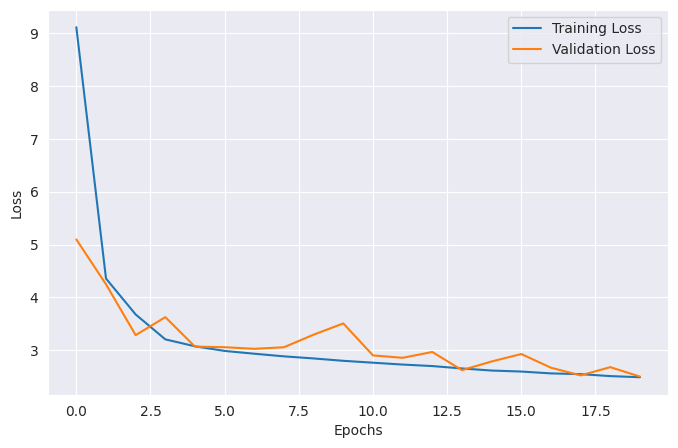

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

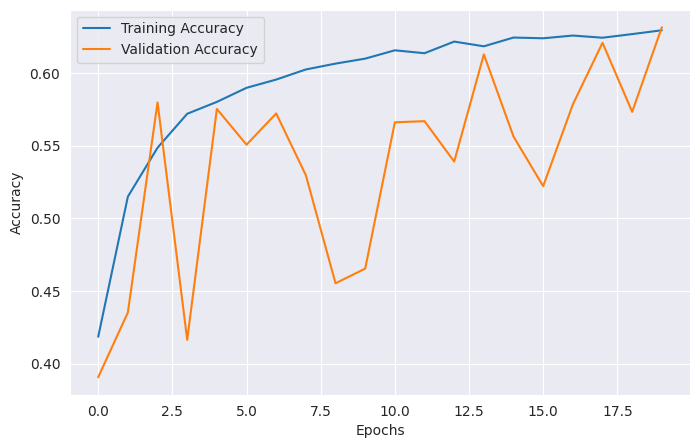

In [26]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, roc_auc_score

In [28]:
def report(y_test, y_pred, class_names):
  y_pred = model.predict(X_test).argmax(axis=1)
  print(classification_report(y_test,y_pred))
  conf_mat = confusion_matrix(y_test,y_pred)
  print(f"Accuracy: {accuracy_score(y_test, y_pred)*100}%")
  print(f"Error: {(1-accuracy_score(y_test, y_pred))*100}%")
  disp = ConfusionMatrixDisplay(conf_mat,display_labels=class_names)
  disp.plot(cmap='Greens')
  disp.ax_.set_title("Confusion Matrix")
  plt.grid(False)
  plt.xticks(rotation=90)
  plt.show()

CNN MODEL
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.64      0.75      0.69      1000
           1       0.79      0.83      0.81      1000
           2       0.50      0.42      0.46      1000
           3       0.40      0.57      0.47      1000
           4       0.55      0.48      0.51      1000
           5       0.63      0.39      0.48      1000
           6       0.63      0.74      0.68      1000
           7       0.59      0.78      0.67      1000
           8       0.92      0.57      0.71      1000
           9       0.80      0.73      0.76      1000

    accuracy                           0.63     10000
   macro avg       0.65      0.63      0.62     10000
weighted avg       0.65      0.63      0.62     10000

Accuracy: 62.6%
Error: 37.4%


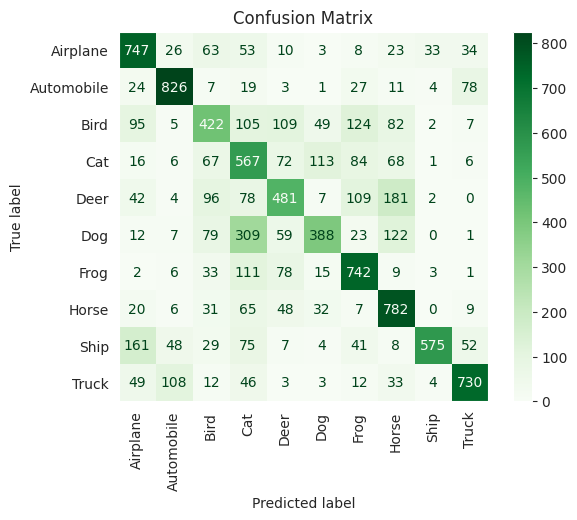

In [29]:
print("CNN MODEL")
report(y_test,y_pred, class_names)

#**Data Augmentation**

In [30]:
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

In [31]:
import tensorflow_datasets as tfds

In [32]:
setattr(tfds.image_classification.cats_vs_dogs, '_URL', url)
(train_ds, val_ds, test_ds), ds_info = tfds.load(
'cats_vs_dogs',
split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
with_info=True,
as_supervised=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.LP2WKE_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [33]:
num_classes = ds_info.features['label'].num_classes
print(num_classes)

2


In [34]:
img_shape = ()
for image, label in train_ds.shuffle(500).take(1):
  print("Image shape: ", image.shape)
  print("Shape shape: ", label.shape)
  img_shape = tuple(image.shape)

  img_shape

Image shape:  (154, 200, 3)
Shape shape:  ()


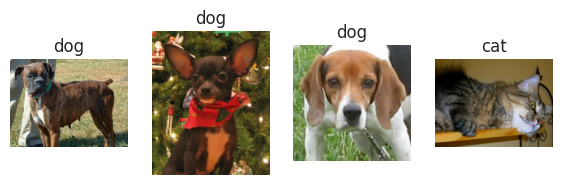

In [35]:
try:
  get_label_name = ds_info.features["label"].int2str
  train_iter = iter(train_ds)
  fig = plt.figure(figsize=(7,8))
  for x in range(4):
    image, label = next(train_iter)
    fig.add_subplot(1, 4, x+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(get_label_name(label))
except StopIteration:
  print("Dataset iterator is empty")


Text(0.5, 1.0, 'dog')

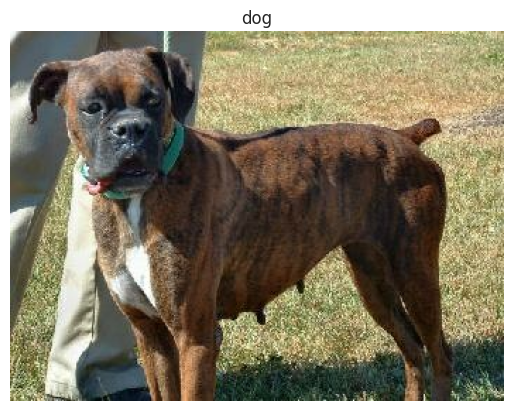

In [36]:
image, label = next(iter(train_ds))
plt.imshow(image)
plt.axis("off")
plt.title(get_label_name(label))

In [37]:
def visualize (original, augmented):
  fig = plt.figure()
  plt.subplot(1,2,1)
  plt.title ("Original Image")
  plt.imshow(original)
  plt.axis("off")

  plt.subplot(1,2,2)
  plt.title ("Augmented Image")
  plt.imshow(augmented)
  plt.axis("off")

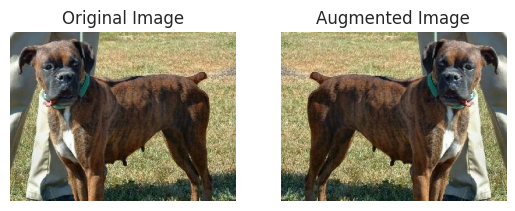

In [38]:
flipped = tf.image.flip_left_right(image)
visualize(image, flipped)

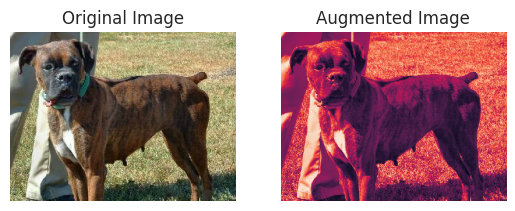

In [39]:
greyscaled = tf.image.rgb_to_grayscale(image)
visualize(image, tf.squeeze(greyscaled))

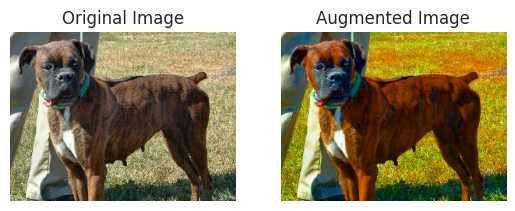

In [40]:
saturated = tf.image.adjust_saturation(image,3)
visualize(image, saturated)

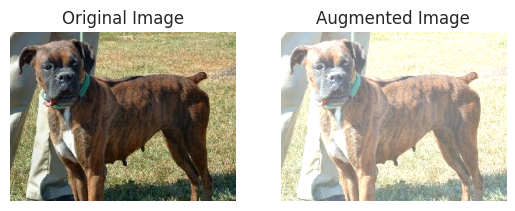

In [41]:
bright = tf.image.adjust_brightness(image,0.4)
visualize(image, bright)

In [42]:
image

<tf.Tensor: shape=(262, 350, 3), dtype=uint8, numpy=
array([[[251, 255, 255],
        [248, 254, 252],
        [242, 246, 245],
        ...,
        [188, 176, 128],
        [142, 132,  81],
        [160, 150,  99]],

       [[247, 253, 251],
        [246, 252, 250],
        [241, 245, 244],
        ...,
        [188, 178, 129],
        [164, 154, 103],
        [176, 166, 115]],

       [[244, 249, 245],
        [244, 249, 245],
        [236, 241, 237],
        ...,
        [197, 187, 138],
        [203, 193, 142],
        [198, 191, 139]],

       ...,

       [[127, 124,  73],
        [149, 146,  95],
        [155, 152, 101],
        ...,
        [165, 170, 140],
        [ 81,  88,  57],
        [ 75,  84,  53]],

       [[167, 164, 113],
        [104, 101,  50],
        [139, 136,  85],
        ...,
        [ 67,  73,  45],
        [ 48,  57,  28],
        [ 38,  49,  19]],

       [[135, 132,  81],
        [ 77,  74,  23],
        [135, 132,  81],
        ...,
        [ 61,  70,  4

In [43]:
bright

<tf.Tensor: shape=(262, 350, 3), dtype=uint8, numpy=
array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 230],
        [244, 234, 183],
        [255, 252, 201]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 231],
        [255, 255, 205],
        [255, 255, 217]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 240],
        [255, 255, 244],
        [255, 255, 241]],

       ...,

       [[229, 226, 175],
        [251, 248, 197],
        [255, 254, 203],
        ...,
        [255, 255, 242],
        [183, 190, 159],
        [177, 186, 155]],

       [[255, 255, 215],
        [206, 203, 152],
        [241, 238, 187],
        ...,
        [169, 175, 147],
        [150, 159, 130],
        [140, 151, 121]],

       [[237, 234, 183],
        [179, 176, 125],
        [237, 234, 183],
        ...,
        [163, 172, 14

In [44]:
image-bright

<tf.Tensor: shape=(262, 350, 3), dtype=uint8, numpy=
array([[[252,   0,   0],
        [249, 255, 253],
        [243, 247, 246],
        ...,
        [189, 177, 154],
        [154, 154, 154],
        [161, 154, 154]],

       [[248, 254, 252],
        [247, 253, 251],
        [242, 246, 245],
        ...,
        [189, 179, 154],
        [165, 155, 154],
        [177, 167, 154]],

       [[245, 250, 246],
        [245, 250, 246],
        [237, 242, 238],
        ...,
        [198, 188, 154],
        [204, 194, 154],
        [199, 192, 154]],

       ...,

       [[154, 154, 154],
        [154, 154, 154],
        [156, 154, 154],
        ...,
        [166, 171, 154],
        [154, 154, 154],
        [154, 154, 154]],

       [[168, 165, 154],
        [154, 154, 154],
        [154, 154, 154],
        ...,
        [154, 154, 154],
        [154, 154, 154],
        [154, 154, 154]],

       [[154, 154, 154],
        [154, 154, 154],
        [154, 154, 154],
        ...,
        [154, 154, 15

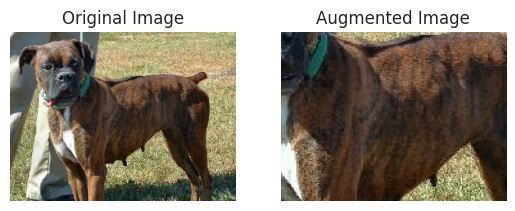

In [45]:
cropped = tf.image.central_crop(image, central_fraction=0.5)
visualize(image, cropped)

In [46]:
cropped

<tf.Tensor: shape=(132, 176, 3), dtype=uint8, numpy=
array([[[ 97, 110, 118],
        [ 65,  79,  82],
        [ 73,  87,  88],
        ...,
        [207, 187, 150],
        [194, 175, 135],
        [205, 186, 144]],

       [[ 51,  61,  70],
        [ 41,  52,  56],
        [ 37,  48,  50],
        ...,
        [203, 180, 149],
        [176, 153, 121],
        [193, 170, 136]],

       [[ 32,  42,  51],
        [ 27,  38,  42],
        [ 13,  24,  26],
        ...,
        [148, 124, 100],
        [137, 113,  87],
        [200, 176, 148]],

       ...,

       [[116, 102,  89],
        [100,  88,  76],
        [113, 103,  91],
        ...,
        [ 50,  31,  14],
        [ 49,  32,  14],
        [ 48,  31,  15]],

       [[ 85,  66,  49],
        [ 93,  76,  60],
        [115,  99,  84],
        ...,
        [ 49,  30,  13],
        [ 47,  30,  12],
        [ 48,  31,  15]],

       [[ 76,  49,  30],
        [ 66,  40,  23],
        [ 86,  63,  45],
        ...,
        [ 49,  30,  1

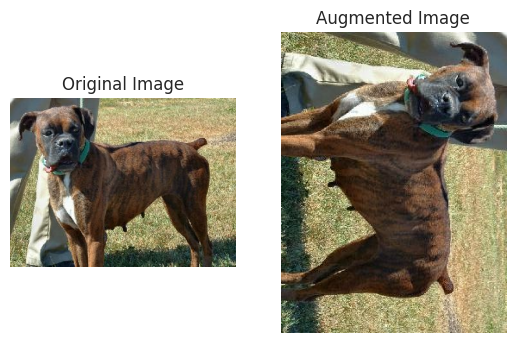

In [47]:
rotate = tf.image.rot90(image, k=3)
visualize(image, rotate)